# XRLF 

### Interactive plot?
##### If you want to be able to rotate the plot (in a Jupyter Notebook) run this cell. Requires ipympl to be installed.

In [27]:
%matplotlib widget

## Import libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['mathtext.default'] = 'regular' #so greek letters are not in italics
# from mpl_toolkits.mplot3d import Axes3D
# from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.collections import PolyCollection
# from matplotlib import animation
from astropy import units as u
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)
import math
import os
from astropy.table import Table
import scipy.stats.distributions as dist
# from scipy.stats import chi2
from scipy.optimize import curve_fit

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14



## Initialise functions

In [12]:
# X-ray flux-luminosity conversions
def X_flux_to_luminosity2(f, redshift, EFmin, EFmax, ELmin, ELmax, tau):
    """
    Function for the conversion of EFmin-EFmax keV observed flux into rest frame ELmin-ELmaxkeV Luminosity.
    :param f: The Observed Flux
    :param redshift: The redshift of the source of the flux
    :param EFmin: The minimum of the energy range of the observed flux
    :param EFmax: The maximum of the energy range of the observed flux
    :param ELmin: The minimum of the energy range of the restframe Luminosity
    :param ELmax: The maximum of the energy range of the restframe Luminosity
    :return: The ELmin-ELmaxkeV rest-frame luminosity
    """
    power = 2.0 - tau
    lumDist = cosmo.luminosity_distance(redshift)
    lumDist = lumDist.to_value(u.cm)
    factor = ((ELmax ** power - ELmin ** power)/(EFmax ** power - EFmin ** power)) / (1 + redshift)**power
    return (4 * np.pi * lumDist**2.0) * factor * f


def X_luminosity_to_flux2(L, redshift, EFmin, EFmax, ELmin, ELmax, tau):
    """
    Function for the conversion of ELmin-ELmaxkeV rest frame luminosity into EFmin-EFmax keV observed flux.
    :param L: The 2-10keV rest frame luminosity
    :param redshift: The redshift at which the luminosity is in the rest frame
    :param EFmin: The minimum energy of the observed flux band
    :param EFmax: The maximum energy of the observed flux band
    :param ELmin: The minimum of the energy range of the restframe Luminosity
    :param ELmax: The maximum of the energy range of the restframe Luminosity
    :param tau: The value of the constant \Tau
    :return: The Emin-Emax keV observed flux
    """
    power = 2.0-tau
    lumDist = cosmo.luminosity_distance(redshift)
    lumDist = lumDist.to_value(u.cm)
    factor = ((EFmax**power - EFmin**power) / (ELmax**power - ELmin**power)) * (1+redshift)**power
    rfFlux = L / (4 * np.pi * lumDist**2.0)
    obsFlux = factor * rfFlux
    return obsFlux

# Radio flux-luminosity conversions
def R_flux_to_luminosity(f, redshift, alpha, freq_flux, freq_lum):
    """
    Converts the observed flux at freq_flux into a rest frame W/m/Hz Luminosity at freq_lum
    :param f: The Observed Flux in milli Jansky
    :param redshift: The redshift of the source of the flux
    :param freq_flux: frequency flux observed at
    :param freq_lum: frequency to calculate luminosity at   
    :alpha: The spectral index
    :return: The rest frame W/m/Hz Luminosity
    """
    power = 1 + alpha
    f = f * 10**(-26) *10**(-3)
    lumDist = cosmo.luminosity_distance(redshift)
    lumDist = lumDist.to_value(u.m)
    factor = ((freq_lum/freq_flux)**alpha) / (1 + redshift)**power
    return (4 * np.pi * lumDist**2.0) * factor * f


def R_luminosity_to_flux(L, redshift, alpha, freq_flux, freq_lum):
    """
    Converts the rest frame W/m/Hz Luminosity at freq_lum into a observed flux at freq_flux 
    :param L: Luminosity in W/m/Hz
    :param redshift: The redshift of the source of the flux
    :param freq_flux: frequency flux observed at
    :param freq_lum: frequency luminosity is calculated at  
    :alpha: The spectral index
    :return: observed Flux in milli Jansky
    """
    power = 1 + alpha
    lumDist = cosmo.luminosity_distance(redshift)
    lumDist = lumDist.to_value(u.m)
    factor = ((freq_flux/freq_lum)**alpha) * (1 + redshift)**power
    f = L / (4 * np.pi * lumDist**2.0)
    f = f * factor
    f = f / (10**(-26)*10**(-3))
    return f


# Functions to obtain area of sky visible (X-ray only) for each source
def area_func_cosmos20(L, redshift, tau, EFmin, EFmax, ELmin, ELmax, band):
    """
    Function for obtaining the area of sky visible by Athena at a specific redshift and source luminosity.
    :param L: The rest frame 2-10keV x-ray luminosity of the sources
    :param redshift: The redshift of the sources
    :param tau: The value of the constant \Tau, for the flux conversion, from the slope of N(E) = AE^{-\Tau}
    :param EFmin: The minimum energy of the observed flux band
    :param EFmax: The maximum energy of the observed flux band
    :param ELmin: The minimum of the energy range of the restframe Luminosity
    :param ELmax: The maximum of the energy range of the restframe Luminosity
    :param band: Is it the full band (0), soft band (1) or hard band (2)
    :return: The area that can be observed at the given redshift and luminosity
    """
    flux = X_luminosity_to_flux2(L, redshift, EFmin, EFmax, ELmin, ELmax, tau)   # 2-10keV Luminosity to Emin-Emax flux

    """ Read in the data for the hard and soft band area curves """
    areaDataRead = np.array(pd.read_csv('areacurve_cosmosCass_HSCUVista.csv'))  
    
    
    fluxCurve = 10**areaDataRead[:,0]
    areaCurve = areaDataRead[:,1]  # Area, A(f(L_X, z))

    """ Interpolate across the area curves to obtain the observed area at each luminosity in L """
    area = np.interp(flux, fluxCurve, areaCurve)

    return area

def area_func_bootes(L, redshift, tau, EFmin, EFmax, ELmin, ELmax, band):
    """
    Function for obtaining the area of sky visible by Athena at a specific redshift and source luminosity.
    :param L: The rest frame 2-10keV x-ray luminosity of the sources
    :param redshift: The redshift of the sources
    :param tau: The value of the constant \Tau, for the flux conversion, from the slope of N(E) = AE^{-\Tau}
    :param EFmin: The minimum energy of the observed flux band
    :param EFmax: The maximum energy of the observed flux band
    :param ELmin: The minimum of the energy range of the restframe Luminosity
    :param ELmax: The maximum of the energy range of the restframe Luminosity
    :param band: Is it the full band (0), soft band (1) or hard band (2)
    :return: The area that can be observed at the given redshift and luminosity
    """
    flux = X_luminosity_to_flux2(L, redshift, EFmin, EFmax, ELmin, ELmax, tau)   # 2-10keV Luminosity to Emin-Emax flux

    """ Read in the data for the hard and soft band area curves """
    if band==0:
        areaDataRead = np.array(pd.read_csv('cdwfs_sens_broad.csv')) 
    elif band==1:
        areaDataRead = np.array(pd.read_csv('cdwfs_sens_soft.csv')) 
    elif band==2:
        areaDataRead = np.array(pd.read_csv('cdwfs_sens_hard.csv')) 
    else:
        print('Error: Pick numbers 0, 1 or 2')
    
    
    fluxCurve = areaDataRead[:,0]  
    areaCurve = areaDataRead[:,1]  # Area, A(f(L_X, z))

    """ Interpolate across the area curves to obtain the observed area at each luminosity in L """
    area = np.interp(flux, fluxCurve, areaCurve)

    return area


# Model RLF and XLF for comparison with observed ################################

def Novak2018_RLF(L1, L2, z1, z2):
    """
    The PLE model of AGN X-ray luminosity function, as modeled by Novak et.al. (2018).

    Parameters
    ----------
    L1 : logged Radio luminosity minimum value
    L2 : logged Radio luminosity maximum value
    z1 : minimum redshift
    z2 : maximum redshift


    Returns
    -------
    Phi/dlogL

    """
    logLr = np.arange(L1, L2, 0.1)#np.arange(min(mid_L)-0.5, max(mid_L)+0.5, 0.1)
    Lr = 10**logLr

    z = (z1+z2)/2 # choose the centre of the redshift bin

    a_SF = 2.95
    B_SF = -0.29
    a_AGN = 2.86
    B_AGN = -0.70

    phi_star1 = 3.55e-3
    L_star1 = 1.85e21
    a1 = 1.22
    sig = 0.63

    efacSF = ((1+z)**(a_SF+z*B_SF))
    LrSF = Lr/efacSF
    efacAGN = ((1+z)**(a_AGN+z*B_AGN))
    LrAGN = Lr/efacAGN

    phi_SF = phi_star1*((LrSF/L_star1)**(1-a1))*np.exp((-1/(2*(sig**2)))*((np.log10(1+(LrSF/L_star1)))**2))

    phi_star2 = (1/0.4)*(10**(-5.5))
    L_star2 = 10**24.59
    a2 = -1.27
    B = -0.49

    phi_AGN = phi_star2/(((L_star2/LrAGN)**a2)+((L_star2/LrAGN)**B)) 
    phi_mod = phi_SF + phi_AGN
    
    return logLr, phi_mod, phi_SF, phi_AGN        
    
def ueda_XLF(Lx, z):
    """
    The Luminosity Dependent Density Evolution (LDDE) model of AGN X-ray luminosity function, fitted to the redshift
    range z=0-5, as modeled by Ueda et.al. (2014).
    :param Lx: logged X-ray luminosity array (independent variables)
    :param z: redshift
    :return:
    """
    h70 = cosmo.H0 / (70 * u.km / u.Mpc / u.s)
    # Initialise the variables
    A = 2.91
    Lstar_0 = 43.97
    gamma1 = 0.96
    gamma2 = 2.71
    p = 4.78
    beta = 0.84
    La1 = 44.61
    zstar_c1 = 1.86
    alpha1 = 0.29

    p1 = p + beta * (Lx - 44.0)
    p2 = -1.5
    p3 = -6.2

    # calculate z_c1 and z_c2 values based on the luminosity conditions
    zc1 = np.where(Lx <= La1, zstar_c1 * ((10 ** Lx / 10 ** La1) ** alpha1), zstar_c1)
    zc2 = np.where(Lx <= 44.0, 3.0 * ((10 ** Lx / 10 ** 44) ** -0.1), 3.0)

    # calculate the evolving parameter values based on the luminosity and redshift conditions
    # The where function is of the form (condition, value if satisfied, value if not satisfied)
    e = np.where(z <= zc1, (1 + z) ** p1,
                    ((1 + zc1) ** p1) * (((1 + z) / (1 + zc1)) ** p2))  # apply the z<=z_c1 condition first
    # now apply the zc2 condition, leaving the values that don't satisfy this as those given by the zc1 condition
    e = np.where(z > zc2, ((1 + zc1) ** p1) * (((1 + zc2) / (1 + zc1)) ** p2) * (((1 + z) / (1 + zc2)) ** p3), e)
    # Calculate the XLF
    faintEnd = ((10 ** Lx) / (10 ** Lstar_0)) ** gamma1
    brightEnd = ((10 ** Lx) / (10 ** Lstar_0)) ** gamma2
    phi = ((A * 1e-6 * h70.value ** 3.0) / (faintEnd + brightEnd)) * e
    return phi


def Aird2015_XLF(logLx, z, band):
    """
    The FDPL model of AGN X-ray luminosity function, as modeled by Aird et.al. (2015).

    Parameters
    ----------
    Lx : logged X-ray luminosity array (independent variables)
    z : redshift
    band : 1=soft, 2=hard

    Returns
    -------
    Phi/dlogL

    """
    C = np.log10(1+z)
    Lx = 10**logLx
    
    if band==2:
        logK = -5.13 + 4.73*C - 7.1*(C**2)        
        logLstar = 43.53 + 1.23*C + 3.35*(C**2) - 4.08*(C**3)       
        logy1 = -0.17 - 0.51*C       
        y2 = 2.31
    elif band==1:
        logK = -5.47 + 4.88*C - 7.2*(C**2)
        logLstar = 43.81 - 0.27*C + 6.82*(C**2) - 6.94*(C**3)
        logy1 = -0.18 - 0.55*C
        y2 = 2.34
    K = 10**logK
    Lstar = 10**logLstar
    y1 = 10**logy1
    
    phi = K*((((Lx/Lstar)**y1) + ((Lx/Lstar)**y2))**(-1))
    return phi


# Miscellaneous ###############################################################
def polygon_under_graph(x, y):
    """
    Construct the vertex list which defines the polygon filling the space under
    the (x, y) line graph. This assumes x is in ascending order.
    """
    return [*zip(x, y)]

## Choose the redshift range from $z_1$ to $z_2$

In [13]:
z1=0.5
z2=1

if z1>=z2:
    print('Warning: $z_2$ must be greater than $z_1$')

## Load catalogue

In [14]:
RXcobo = pd.read_csv('X-ray_Radio_Bootes_COSMOS_v5.csv')

## Initialse and calculate necessary parameters

In [ ]:
gamma = 1.9 # Used to calculate the X-ray luminosity from flux, see Pennock et al. 2025 for more. 
band=0 # Indicates using broad band, 1 is the soft band, 2 is the hard band
lowband = 0.5#keV the lower range of the X-ray detection in Chandra, broad band
uppband = 7#keV the upper range of the X-ray detection in Chandra, broad band

alpha = -0.7# Slope of the expected radio SED
Rband1 = 144#MHz Bootes 
Rband2 = 3000#MHz COSMOS


# Quality cuts 
RXcobo = RXcobo[((RXcobo["Cat"]=="Bootes") & (RXcobo['Fprob'] < 10**(-4.63))  & (RXcobo['FFlux_bay'] > 0)) | ((RXcobo["Cat"]=="COSMOS") & (RXcobo['Fprob'] < (4*10**(-6))) & (RXcobo['Fprob'] > 0) & (RXcobo['FFlux_bay'] > 0))]

# Select those in the desired redshift
RXcobo = RXcobo[RXcobo['Z_BEST']<=z2]
RXcobo = RXcobo[RXcobo['Z_BEST']>=z1]
RXcobo = RXcobo.dropna(subset=['Z_BEST']) # Remove sources with no z info

# Reset index of dataframe, so loops work later
RXcobo.reset_index(drop=True, inplace=True)

# Calculate X-ray luminosity
RXcobo['LumX'] = X_flux_to_luminosity2(RXcobo["FFlux_bay"].to_numpy(), RXcobo["Z_BEST"].to_numpy(), lowband, uppband, 2, 10, gamma)

# Calculate radio luminosity (N.B. flux must be in mJy, Bootes LOFAR was in Jy and COSMOS VLA was in uJy)
RXcobo['LumR'] = np.nan
RXcobo['LumR'][RXcobo.Cat=="Bootes"] = R_flux_to_luminosity((RXcobo['Total_flux']*10**3).to_numpy(), RXcobo['Z_BEST'].to_numpy(), -0.7, 144, 1400) 
RXcobo['LumR'][RXcobo.Cat=="COSMOS"] = R_flux_to_luminosity((RXcobo['Total_flux']*10**(-3)).to_numpy(), RXcobo['Z_BEST'].to_numpy(), -0.7, 3000, 1400) 


#Bootes Survey area ###############
areaDataRead1 = np.array(pd.read_csv('cdwfs_sens_broad.csv')) 

fluxCurveX1 = areaDataRead1[:,0]  

# Set a minimum flux lim, under which nothing is detected
FluxX_lim1 = min(fluxCurveX1) 

# Set flux above which can be detected for entire area
FluxX_upp1 = max(fluxCurveX1) 

# COSMOS area curve ##################
areaDataRead2 = np.array(pd.read_csv('areacurve_cosmosCass_HSCUVista.csv')) 

fluxCurveX2 = areaDataRead2[:,0]  

# Set a minimum flux lim, under which nothing is detected
FluxX_lim2 = min(10**fluxCurveX2) 

# Set flux above which can be detected for entire area
FluxX_upp2 = max(10**fluxCurveX2)


# Flux limits of the radio surveys in mJy
FluxR_lim1 = 0.32 # Bootes
FluxR_lim2 = 0.004 # COSMOS

# Area of the Bootes and COSMOS surveys
Area1 = (9.3*u.deg**2).to(u.steradian).value # Bootes
Area2 = (1.35*u.deg**2).to(u.steradian).value # COSMOS


/var/folders/57/_g9lt4c50jdgydyk5sjs8jdw0000gn/T/ipykernel_39618/3264789828.py:26: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  RXcobo['LumR'][RXcobo.Cat=="Bootes"] = R_flux_to_luminosity((RXcobo['Total_flux']*10**3).to_numpy(), RXcobo['Z_B

## Choose the X-ray and radio luminosity bin ranges to calculate Phi over

In [ ]:
# Create the array of redshifts to iterate over
zn = 100 # number of redshift bins to calculate
zrange = np.linspace(z1, z2, zn)
dz = zrange[1]-zrange[0]

# Number of bins in X-ray luminosity (nx) and radio luminosity (nr)
nx = 10
nr = 12

# Minimum and maximum luminosity ranges in X-ray (lxmin,lxmax) and radio (lrmin,lrmax) to measure the XRLF over
lxmin = 40
lxmax = 46
lrmin = 20
lrmax = 28

# The centres of the luminosity bins
logLx = np.linspace(lxmin,lxmax,nx)
dlogLx = logLx[1]-logLx[0]
logLr = np.linspace(lrmin,lrmax,nr)
dlogLr = logLr[1]-logLr[0]

# The edsges of the lumionsity bins
binedgesx = np.append(logLx-dlogLx/2,logLx[-1]+dlogLx/2)
binedgesr = np.append(logLr-dlogLr/2,logLr[-1]+dlogLr/2)

# Create array of X-ray bins and radio luminosity bins
logLx_2d, logLr_2d = np.meshgrid(logLx, logLr)

# Get the counts per bin of the X-ray and radio luminosity bins
Nall, xedges, yedges = np.histogram2d(np.log10(RXcobo["LumR"]), np.log10(RXcobo["LumX"]), bins=[binedgesr,binedgesx])

# Create the array to save the volume for each X-ray-radio luminosity bin
Vall = np.zeros(np.shape(logLx_2d))

## Measure the XRLF

In [ ]:
# Initialse arrays to sum volume and space density in
Vall = 0
Phi = 0

# iterate over incremental ranges of redshift
for a in range(0,len(zrange)):

    dVdz = cosmo.differential_comoving_volume(zrange[a])
    
    # Bootes X-ray
    # Get X-ray flux from luminosities and z   
    fx1 = X_luminosity_to_flux2( 10**logLx_2d, zrange[a], lowband, uppband, 2, 10,gamma)
   
    # Get Area a source can be observed from X-ray flux in Bootes
    Ax1 = np.zeros(np.shape(fx1))
    Ax1[np.where(fx1<=FluxX_lim1)] = 0 # flux limit is below Radio sensitivity
    Ax1[np.where(fx1>=FluxX_upp1)] = Area1 # flux limit always above maximum
    s,junk = np.where((fx1>FluxX_lim1) & (fx1<FluxX_upp1)) # for all other fluxes, interpolate area curve
    if np.count_nonzero(s):
            Ax1[s] = (area_func_bootes(10**logLx_2d[s], zrange[a], gamma, lowband, uppband, 2, 10, band)*u.deg**2).to(u.steradian).value
     
        
    # COSMOS X-ray 
    # Get X-ray flux from luminosities and z 
    fx2 = X_luminosity_to_flux2( 10**logLx_2d, zrange[a], lowband, uppband, 2, 10,gamma)
   
    # Get Area a source can be observed from X-ray flux in COSMOS
    Ax2 = np.zeros(np.shape(fx2))
    Ax2[np.where(fx2<=FluxX_lim2)] = 0 # flux limit is below Radio sensitivity
    Ax2[np.where(fx2>=FluxX_upp2)] = Area2 # flux limit always above maximum
    s,junk = np.where((fx2>FluxX_lim2) & (fx2<FluxX_upp2)) # for all other fluxes, interpolate area curve
    if np.count_nonzero(s):
            Ax2[s] = (area_func_cosmos20(10**logLx_2d[s], zrange[a], gamma, lowband, uppband, 2, 10, band)*u.deg**2).to(u.steradian).value



    # Bootes Radio
    # Get Radio flux from luminosities and z
    fr1 = R_luminosity_to_flux(10**logLr_2d, zrange[a], alpha, Rband1, 1400)
    
    # Get Area a source can be observed from radio flux in Bootes
    Ar1 = np.zeros(np.shape(fr1))
    # Ar = ar_func(fr)
    Ar1[np.where(fr1<FluxR_lim1)] = 0 # flux limit is below Radio sensitivity
    Ar1[np.where(fr1>=FluxR_lim1)] = Area1 # flux limit always above maximum

    # Get min Area a source can be observed in radio and X-ray in Bootes
    Amin1 = Ar1.copy()          
    w=( (Ar1 - Ax1) > 0)
    Amin1[w] = Ax1[w]
    
    # calculate volume and get volume array for Bootes
    Vol1 = Amin1*(u.steradian) * dVdz.to((u.Mpc)**3/(u.steradian)) * dlogLx * dlogLr * dz
    
    
    # COSMOS Radio
    # Get Radio flux from luminosities and z
    fr2 = R_luminosity_to_flux(10**logLr_2d, zrange[a], alpha, Rband2, 1400)
    
    # Get Area a source can be observed from radio flux in COMSOS
    Ar2 = np.zeros(np.shape(fr2))
    # Ar = ar_func(fr)
    Ar2[np.where(fr2<FluxR_lim2)] = 0 # flux limit is below Radio sensitivity
    Ar2[np.where(fr2>=FluxR_lim2)] = Area2 # flux limit always above maximum

    # Get min Area a source can be observed in radio and X-ray in COSMOS
    Amin2 = Ar2.copy()          
    w=( (Ar2 - Ax2) > 0)
    Amin2[w] = Ax2[w]
    
    # calculate volumne and get volume array for COSMOS
    Vol2 = Amin2*(u.steradian) * dVdz.to((u.Mpc)**3/(u.steradian)) * dlogLx * dlogLr * dz

    # Combine volume from Bootes and COSMOS in each redshift bin
    Vol12 = Vol1 + Vol2 
    
    # Sum the volume in each lum bin for each redshift bin
    Vall = Vall + Vol12 
    
# Calculate Phi (density of sources)
Phi = Nall / Vall

# Get the value without the units
Phi = Phi.value

#% Error calculations for Phi using poisson errors
phi_low = np.zeros(np.shape(logLx_2d))
phi_upp = np.zeros(np.shape(logLx_2d))

for ex in range(0, len(phi_low[:,0])):
    for ey in range(0, len(phi_low[0,:])):
        if Nall[ex, ey]<100:
            phi_low[ex,ey] = math.dist((Phi[ex,ey],), (((Phi[ex,ey]*((Nall[ex,ey]*(1-(1/(9*Nall[ex,ey]))-(1/(3*np.sqrt(Nall[ex,ey]))))**3)/Nall[ex,ey]))),))
            phi_upp[ex,ey] = (Phi[ex,ey]*((np.sqrt(Nall[ex,ey]+1)+1)/Nall[ex,ey]))
        else:
            phi_low[ex,ey] = (Phi[ex,ey]*(np.sqrt(Nall[ex,ey]))/Nall[ex,ey])
            phi_upp[ex,ey] = (Phi[ex,ey]*(np.sqrt(Nall[ex,ey]))/Nall[ex,ey])

Phi[Phi==0] = np.nan # necessary for the 3D plot later.

/Users/cmpennock/opt/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/var/folders/57/_g9lt4c50jdgydyk5sjs8jdw0000gn/T/ipykernel_39618/3730651297.py:93: RuntimeWarning: divide by zero encountered in scalar divide
  phi_low[ex,ey] = math.dist((Phi[ex,ey],), (((Phi[ex,ey]*((Nall[ex,ey]*(1-(1/(9*Nall[ex,ey]))-(1/(3*np.sqrt(Nall[ex,ey]))))**3)/Nall[ex,ey]))),))
/var/folders/57/_g9lt4c50jdgydyk5sjs8jdw0000gn/T/ipykernel_39618/3730651297.py:93: RuntimeWarning: invalid value encountered in scalar multiply
  phi_low[ex,ey] = math.dist((Phi[ex,ey],), (((Phi[ex,ey]*((Nall[ex,ey]*(1-(1/(9*Nall[ex,ey]))-(1/(3*np.sqrt(Nall[ex,ey]))))**3)/Nall[ex,ey]))),))
/var/folders/57/_g9lt4c50jdgydyk5sjs8jdw0000gn/T/ipykernel_39618/3730651297.py:94: RuntimeWarning: divide by zero encountered in scalar divide
  phi_upp[ex,ey] = (Phi[ex,ey]*((np.sqrt(Nall[ex,ey]+1)+1)/Nal

## Save new array

In [ ]:

# stringphi = 'XRLF_phi' + f'{z1}to{z2}' + '.csv' 
# stringphiupp = 'XRLF_phi_upperr' + f'{z1}to{z2}' + '.csv' 
# stringphilow = 'XRLF_phi_lowerr' + f'{z1}to{z2}' + '.csv' 
# Phi2 = pd.DataFrame(Phi)
# Phi2.columns = np.round(logLx_2d[0,:], decimals=2)
# Phi2.index = np.round(logLr_2d[:,0], decimals=2)
# Phi2.to_csv(stringphi)
# Phi2upp = pd.DataFrame(phi_upp)
# Phi2upp.columns = np.round(logLx_2d[0,:], decimals=2)
# Phi2upp.index = np.round(logLr_2d[:,0], decimals=2)
# Phi2upp.to_csv(stringphiupp)
# Phi2low = pd.DataFrame(phi_low)
# Phi2low.columns = np.round(logLx_2d[0,:], decimals=2)
# Phi2low.index = np.round(logLr_2d[:,0], decimals=2)
# Phi2low.to_csv(stringphilow)


## Plot in 3D

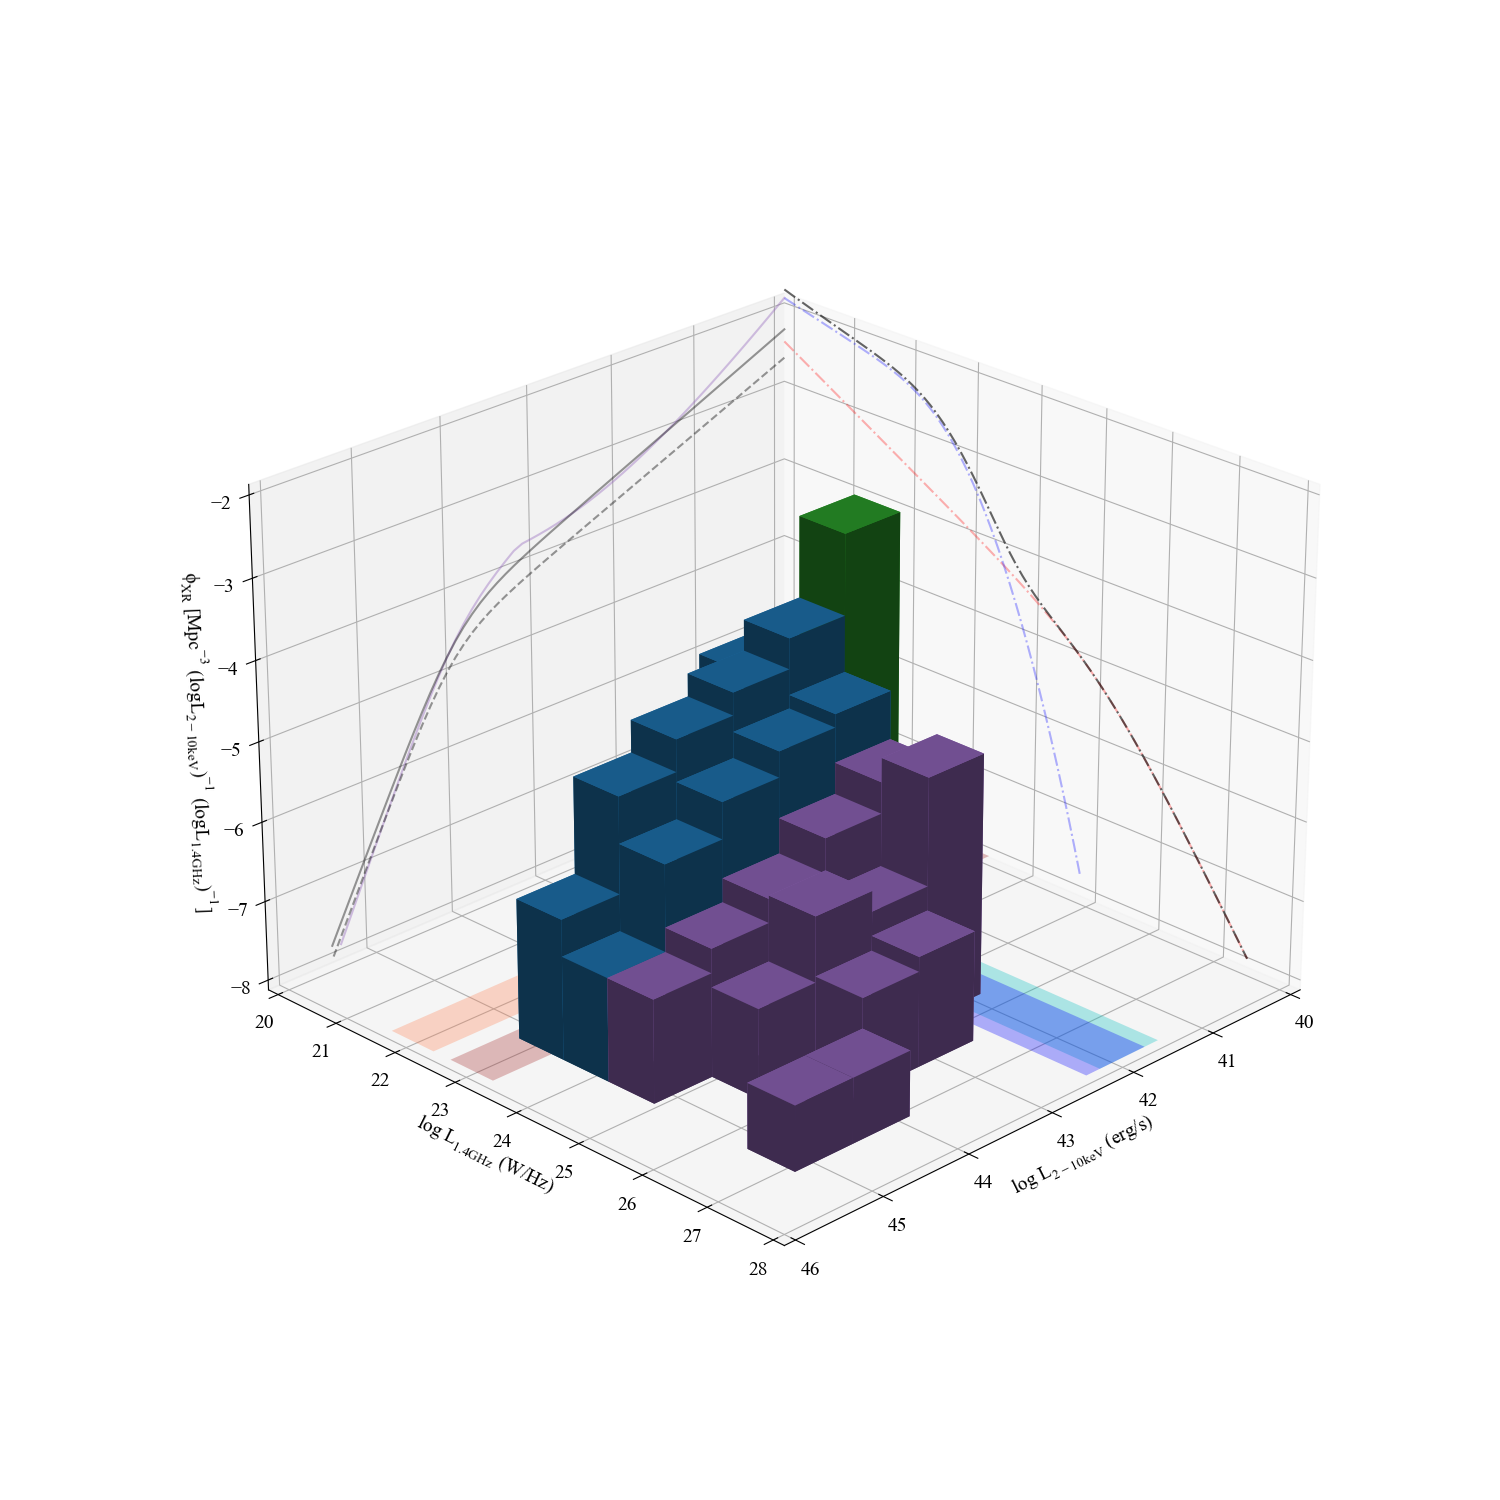

In [28]:
# Initialise the 3D plot with a grid
fig = plt.figure(figsize = (15,15))
ax = plt.axes(projection='3d')
ax.grid()



##### Plot limits of surveys first, so they don't block the main 3D figure ############
lumxzC1 =  X_flux_to_luminosity2(5.95e-16,z1 , lowband, uppband, 2, 10, gamma)
lumxzC2 =  X_flux_to_luminosity2(5.95e-16,z2 , lowband, uppband, 2, 10, gamma)
lumxzB1 = X_flux_to_luminosity2(8.75e-16,z1 , lowband, uppband, 2, 10, gamma)  
lumxzB2 = X_flux_to_luminosity2(8.75e-16,z2 , lowband, uppband, 2, 10, gamma)  
lumrzB1 = R_flux_to_luminosity(0.32, z1, -0.7, 144, 1400) 
lumrzB2 = R_flux_to_luminosity(0.32, z2, -0.7, 144, 1400) 
lumrzC1 = R_flux_to_luminosity(0.004, z1, -0.7, 3000, 1400)
lumrzC2 = R_flux_to_luminosity(0.004, z2, -0.7, 3000, 1400)

if np.log10(lumxzB1)<40:
    vertsBx = [polygon_under_graph([40, 40, np.log10(lumxzB2), np.log10(lumxzB2)], [20,28, 28, 20])]
else:
    vertsBx = [polygon_under_graph([np.log10(lumxzB1), np.log10(lumxzB1), np.log10(lumxzB2), np.log10(lumxzB2)], [20,28, 28, 20])]
  
if np.log10(lumxzC1)<40:
    vertsCx = [polygon_under_graph([40, 40, np.log10(lumxzC2), np.log10(lumxzC2)], [20,28, 28, 20])]
else:
    vertsCx = [polygon_under_graph([np.log10(lumxzC1), np.log10(lumxzC1), np.log10(lumxzC2), np.log10(lumxzC2)], [20,28, 28, 20])]

if np.log10(lumrzC1)<20:
    vertsCr = [polygon_under_graph([40,46, 46, 40],[20, 20, np.log10(lumrzC2), np.log10(lumrzC2)])]
else:
    vertsCr = [polygon_under_graph([40,46, 46, 40],[np.log10(lumrzC1), np.log10(lumrzC1), np.log10(lumrzC2), np.log10(lumrzC2)])]

if np.log10(lumrzB1)<20:
    vertsBr = [polygon_under_graph([40,46, 46, 40],[20, 20, np.log10(lumrzB2), np.log10(lumrzB2)])]
else:
    vertsBr = [polygon_under_graph([40,46, 46, 40],[np.log10(lumrzB1), np.log10(lumrzB1), np.log10(lumrzB2), np.log10(lumrzB2)])]

polyCx = PolyCollection(vertsCx, facecolors='c', alpha=0.3)#, label="COSMOS X-ray flux limits")
ax.add_collection3d(polyCx, zs=-8, zdir='z')

polyBx = PolyCollection(vertsBx, facecolors='b', alpha=0.3)#, label="Bootes X-ray flux limits")
ax.add_collection3d(polyBx, zs=-8, zdir='z')

polyCr = PolyCollection(vertsCr, facecolors='coral', alpha=0.3)#, label="COSMOS Radio flux limits")
ax.add_collection3d(polyCr, zs=-8, zdir='z')


polyBr = PolyCollection(vertsBr, facecolors='brown', alpha=0.3)#, label="Bootes X-ray flux limits")
ax.add_collection3d(polyBr, zs=-8, zdir='z')

############################################################################################

# Create colour array for the 3D plot ############
aa=np.full(np.shape(logLx_2d), -8)
colours=np.full(np.shape(logLx_2d), 'tab:purple') # purple indicates both X-ray and radio are most likely from AGN emission

# Use RLF model to determine where AGN dominate of SF sources depending on redshift.
loggyLr, phi_mod, phi_SF, phi_AGN = Novak2018_RLF(20, 28, z1, z2)

Rcp=np.where(phi_SF<=phi_AGN)[0][0]

# Use Lx>10^{42} erg/s as indication of an X-ray AGN
colours[logLx_2d<42] = 'tab:olive' # SF in X-ray, AGN in Radio
colours[logLr_2d<loggyLr[Rcp]] = 'tab:blue' # AGN in X-ray, SF in radio 
colours[(logLr_2d<loggyLr[Rcp]) & (logLx_2d<42)] = 'tab:green' # SF in radio and X-ray

################################################

# The 3D plot
ax.bar3d(x=logLx_2d.flatten(),y=logLr_2d.flatten(),z=aa.flatten(), dx=dlogLx, dy=dlogLr, dz=(8-abs(np.log10(Phi))).flatten(), color=colours.flatten())
# z is the bottom of the bar and dz is the height from this lower point you want to plot. In logspace so can't pick 0.


# Label axes
ax.set_xlabel("log L$_{2-10keV}$ (erg/s)")
ax.set_ylabel("log L$_{1.4 GHz}$ (W/Hz)")
ax.set_zlabel("$\phi_{XR}$ [Mpc$^{-3}$ (logL$_{2-10keV}$)$^{-1}$ (logL$_{1.4 GHz}$)$^{-1}$]")

ax.set_zlim([-8, -2])

ax.set_ylim([20,28])
ax.set_xlim([40,46])



# By using zdir='y', the y value of these points is fixed to the zs value 0
# and the (x, y) points are plotted on the x and z axes.
# ax.plot(x, y, zs=0, zdir='y', c=c_list, label='points in (x, z)')


# Lr vs Phi axis
# Add RLF model
L1=20
L2=28
logLr, phi_mod, phi_SF, phi_AGN = Novak2018_RLF(L1, L2, z1, z2)
ax.plot(loggyLr[np.log10(phi_AGN/dlogLx)>=-8], np.log10(phi_AGN[np.log10(phi_AGN/dlogLx)>-8]/dlogLx), zs=40, zdir='x', c='r',linestyle='-.', alpha=0.3)
ax.plot(loggyLr[np.log10(phi_SF/dlogLx)>=-8], np.log10(phi_SF[np.log10(phi_SF/dlogLx)>=-8]/dlogLx), zs=40, zdir='x',c='b',linestyle='-.', alpha=0.3)
ax.plot(loggyLr[np.log10(phi_mod/dlogLx)>=-8], np.log10(phi_mod[np.log10(phi_mod/dlogLx)>=-8]/dlogLx), zs=40, zdir='x', c='k' ,linestyle='-.',alpha=0.6,label=f"Novak et al. 2018")#, z={(z1+z2)/2}")


# Lx vs Phi axis
# Add XLF model
Lx = np.arange(40, 46, 0.1)

z=(z1+z2)/2 # choose the centre of the redshift bin
Uedaphi = ueda_XLF(Lx, z)
AirdHphi = Aird2015_XLF(Lx, z, 2)
AirdSphi = Aird2015_XLF(Lx, z, 1)

ax.plot(Lx[np.log10((Uedaphi).astype(float)/dlogLr)>=-8], np.log10((Uedaphi[np.log10((Uedaphi).astype(float)/dlogLr)>=-8]).astype(float)/dlogLr), zs=20, zdir='y', c='tab:purple', alpha=0.4,   label=f'Ueda et al. 2014')#, z = {z:.2f}')
ax.plot(Lx[np.log10(AirdHphi/dlogLr)>=-8], np.log10(AirdHphi[np.log10(AirdHphi/dlogLr)>=-8]/dlogLr),zs=20, zdir='y', c='k', alpha=0.4,  label=f'Aird et al. 2015 (Hard)')#, z = {z:.2f}')
ax.plot(Lx[np.log10(AirdSphi/dlogLr)>=-8], np.log10(AirdSphi[np.log10(AirdSphi/dlogLr)>=-8]/dlogLr), zs=20, zdir='y', c='k', linestyle='--', alpha=0.4,  label=f'Aird et al. 2015 (Soft)')#, z = {z:.2f}')


# Set the viewing angle of the plot.
ax.view_init(elev=25., azim=45)

# Add legend, sometimes can be awkwardly placed.
# plt.legend()